# 01 Quickstart: Trajectory Workflow

**Learning goals**

- Build the TAL mental model: xarray data plus declared trajectory roles.
- Distinguish batch, sequence, core, param, and validity metadata.
- See that param evaluation and typed wrappers preserve trajectory semantics.

A trajectory is an ordered set of samples along a meaningful progression axis. TAL makes that structure explicit so later operations can preserve it.


## The example shape

This notebook uses a small `trial x sample x axis` dataset.

| Dimension/coordinate | TAL role | Meaning |
|---|---|---|
| `trial` | batch dim | independent recorded runs |
| `sample` | sequence dim | ordered samples within each run |
| `axis` | core dim | xyz payload components |
| `time_s` | param coordinate | physical time used for interpolation |
| `group_size` | validity coordinate | valid length for each padded run |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from IPython.display import display

from tal import AnalysisObject
from tal.core import ParamEvalOptions
from tal.spatial import Position

from pathlib import Path
import sys

_release_dir = Path.cwd()
if not (_release_dir / '_helpers.py').exists():
    candidate = Path.cwd() / 'examples' / 'release'
    if candidate.exists():
        _release_dir = candidate
if str(_release_dir) not in sys.path:
    sys.path.append(str(_release_dir))

from _helpers import (
    build_framegraph_spatial_payloads,
    build_topology_edge_payloads,
    compact_dataset,
    display_result,
    explain_expected_failure,
    make_imu_gps_alignment_aos,
    make_kinematics_demo_objects,
    make_pose_demo_objects,
    show_ao,
    summarize_ao,
)


## Start with labeled xarray data

At this point xarray knows dimension and coordinate names. TAL roles have not been declared yet.


In [2]:
ds = xr.Dataset(
    data_vars={
        'position': (
            ('trial', 'sample', 'axis'),
            np.array(
                [
                    [[0.0, 0.0, 0.0], [0.2, 0.0, 0.0], [0.4, 0.1, 0.0], [0.6, 0.1, 0.0]],
                    [[1.0, 0.0, 0.0], [1.2, 0.1, 0.0], [1.4, 0.1, 0.1], [0.0, 0.0, 0.0]],
                ],
                dtype=float,
            ),
        )
    },
    coords={
        'trial': ['trial_a', 'trial_b'],
        'sample': np.arange(4),
        'axis': ['x', 'y', 'z'],
        'time_s': (
            ('trial', 'sample'),
            np.array([[0.0, 0.2, 0.4, 0.6], [0.0, 0.2, 0.4, 0.6]], dtype=float),
        ),
        'group_size': ('trial', np.array([4, 3], dtype=np.int64)),
    },
)

display(ds)


<xarray.Dataset> Size: 372B
Dimensions:     (trial: 2, sample: 4, axis: 3)
Coordinates:
  * trial       (trial) <U7 56B 'trial_a' 'trial_b'
  * sample      (sample) int64 32B 0 1 2 3
  * axis        (axis) <U1 12B 'x' 'y' 'z'
    time_s      (trial, sample) float64 64B 0.0 0.2 0.4 0.6 0.0 0.2 0.4 0.6
    group_size  (trial) int64 16B 4 3
Data variables:
    position    (trial, sample, axis) float64 192B 0.0 0.0 0.0 ... 0.0 0.0 0.0

## Declare TAL roles

`AnalysisObject.from_data(...)` does not change the values. It records how dimensions should be interpreted.


In [3]:
ao = AnalysisObject.from_data(
    ds,
    sequence_dim='sample',
    batch_dims=('trial',),
    core_dims=('axis',),
    param_coord='time_s',
    sequence_size_coord='group_size',
    validate=True,
)

show_ao('position AO', ao)


#### position AO

,field,value
0,type,AnalysisObject
1,dims,"{'trial': 2, 'sample': 4, 'axis': 3}"
2,data_vars,[position]
3,coords,"[trial, sample, axis, time_s, group_size]"
4,batch_dims,"(trial,)"
5,sequence_dim,sample
6,core_dims,"(axis,)"
7,param_coord,time_s
8,sequence_size_coord,group_size
9,frames,None


<xarray.Dataset> Size: 372B
Dimensions:     (trial: 2, sample: 4, axis: 3)
Coordinates:
  * trial       (trial) <U7 56B 'trial_a' 'trial_b'
  * sample      (sample) int64 32B 0 1 2 3
  * axis        (axis) <U1 12B 'x' 'y' 'z'
    time_s      (trial, sample) float64 64B 0.0 0.2 0.4 0.6 0.0 0.2 0.4 0.6
    group_size  (trial) int64 16B 4 3
Data variables:
    position    (trial, sample, axis) float64 192B 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    tal:      {'version': 1, 'core': {'roles': {'batch_dims': ['trial'], 'cor...

What to notice:

- `sample` is the ordered sequence dimension.
- `trial` is a batch dimension; each trial is independent.
- `axis` is the vector payload dimension, not another time axis.
- `time_s` is the coordinate used for physical-time evaluation.
- `group_size` tells TAL that `trial_b` has one padded sample.


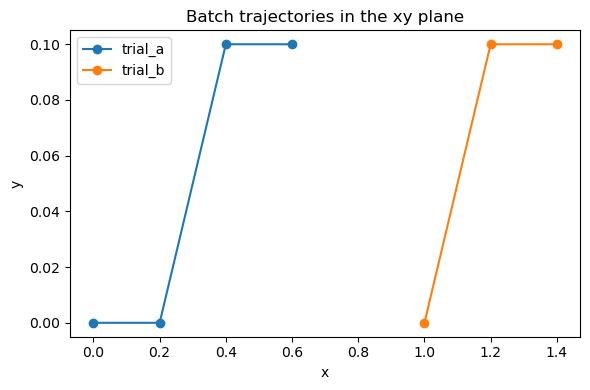

In [4]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print('Plot skipped: matplotlib is not installed.')

if plt is not None:
    fig, ax = plt.subplots(figsize=(6, 4))
    for trial in ao.unsafe_data.coords['trial'].values:
        valid = int(ao.unsafe_data['group_size'].sel(trial=trial))
        path = ao.unsafe_data['position'].sel(trial=trial).isel(sample=slice(0, valid))
        ax.plot(path.sel(axis='x'), path.sel(axis='y'), marker='o', label=str(trial))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Batch trajectories in the xy plane')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()


## Evaluate by parameter values

Use `ao.param` when the question is about physical time, distance, phase, or another progression coordinate.


In [5]:
query = np.array([0.1, 0.3, 0.5], dtype=float)
ao_q = ao.param.at(query, on='time_s', opts=ParamEvalOptions(method='linear'))
ao_r = ao.param.resample_to(np.linspace(0.0, 0.6, 5), on='time_s')

show_ao('ao_q: evaluated at query times', ao_q)
show_ao('ao_r: resampled to a regular grid', ao_r)


#### ao_q: evaluated at query times

,field,value
0,type,AnalysisObject
1,dims,"{'trial': 2, 'axis': 3, 'sample': 3}"
2,data_vars,[position]
3,coords,"[trial, group_size, axis, valid, sample, time_s]"
4,batch_dims,"(trial,)"
5,sequence_dim,sample
6,core_dims,"(axis,)"
7,param_coord,time_s
8,sequence_size_coord,group_size
9,frames,None


<xarray.Dataset> Size: 282B
Dimensions:     (trial: 2, axis: 3, sample: 3)
Coordinates:
  * trial       (trial) <U7 56B 'trial_a' 'trial_b'
  * axis        (axis) <U1 12B 'x' 'y' 'z'
  * sample      (sample) int64 24B 0 1 2
    group_size  (trial) int64 16B 3 2
    valid       (trial, sample) bool 6B True True True True True False
    time_s      (sample) float64 24B 0.1 0.3 0.5
Data variables:
    position    (trial, axis, sample) float64 144B 0.1 0.3 0.5 ... 0.0 0.05 nan
Attributes:
    tal:      {'version': 1, 'core': {'roles': {'batch_dims': ['trial'], 'cor...

#### ao_r: resampled to a regular grid

,field,value
0,type,AnalysisObject
1,dims,"{'trial': 2, 'axis': 3, 'sample': 5}"
2,data_vars,[position]
3,coords,"[trial, group_size, axis, valid, sample, time_s]"
4,batch_dims,"(trial,)"
5,sequence_dim,sample
6,core_dims,"(axis,)"
7,param_coord,time_s
8,sequence_size_coord,None
9,frames,None


<xarray.Dataset> Size: 414B
Dimensions:     (trial: 2, axis: 3, sample: 5)
Coordinates:
  * trial       (trial) <U7 56B 'trial_a' 'trial_b'
  * axis        (axis) <U1 12B 'x' 'y' 'z'
  * sample      (sample) int64 40B 0 1 2 3 4
    group_size  (trial) int64 16B 5 3
    valid       (trial, sample) bool 10B True True True ... True False False
    time_s      (sample) float64 40B 0.0 0.15 0.3 0.45 0.6
Data variables:
    position    (trial, axis, sample) float64 240B 0.0 0.15 0.3 ... 0.05 nan nan
Attributes:
    tal:      {'version': 1, 'core': {'roles': {'batch_dims': ['trial'], 'cor...

What changed?

- The output sequence grid now corresponds to query values.
- Batch and core semantics remain attached.
- TAL handles padded validity while evaluating each trial.


## Add spatial meaning

A 3-vector could be a position, velocity, force, color, or error vector. `Position` declares that this vector payload is spatial position data.


In [6]:
pos = Position(ao)
pos_q = pos.param.at([0.15, 0.45], on='time_s')

show_ao('typed Position', pos)
show_ao('typed Position after param.at', pos_q)
(type(pos).__name__, type(pos_q).__name__)


#### typed Position

,field,value
0,type,Position
1,dims,"{'trial': 2, 'sample': 4, 'axis': 3}"
2,data_vars,[position]
3,coords,"[trial, sample, axis, time_s, group_size]"
4,batch_dims,"(trial,)"
5,sequence_dim,sample
6,core_dims,"(axis,)"
7,param_coord,time_s
8,sequence_size_coord,group_size
9,frames,None


<xarray.Dataset> Size: 372B
Dimensions:     (trial: 2, sample: 4, axis: 3)
Coordinates:
  * trial       (trial) <U7 56B 'trial_a' 'trial_b'
  * sample      (sample) int64 32B 0 1 2 3
  * axis        (axis) <U1 12B 'x' 'y' 'z'
    time_s      (trial, sample) float64 64B 0.0 0.2 0.4 0.6 0.0 0.2 0.4 0.6
    group_size  (trial) int64 16B 4 3
Data variables:
    position    (trial, sample, axis) float64 192B 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    tal:      {'version': 1, 'core': {'roles': {'batch_dims': ['trial'], 'cor...

#### typed Position after param.at

,field,value
0,type,Position
1,dims,"{'trial': 2, 'axis': 3, 'sample': 2}"
2,data_vars,[position]
3,coords,"[trial, group_size, axis, valid, sample, time_s]"
4,batch_dims,"(trial,)"
5,sequence_dim,sample
6,core_dims,"(axis,)"
7,param_coord,time_s
8,sequence_size_coord,group_size
9,frames,None


<xarray.Dataset> Size: 216B
Dimensions:     (trial: 2, axis: 3, sample: 2)
Coordinates:
  * trial       (trial) <U7 56B 'trial_a' 'trial_b'
  * axis        (axis) <U1 12B 'x' 'y' 'z'
  * sample      (sample) int64 16B 0 1
    group_size  (trial) int64 16B 2 1
    valid       (trial, sample) bool 4B True True True False
    time_s      (sample) float64 16B 0.15 0.45
Data variables:
    position    (trial, axis, sample) float64 96B 0.15 0.45 0.0 ... nan 0.0 nan
Attributes:
    tal:      {'version': 1, 'core': {'roles': {'batch_dims': ['trial'], 'cor...

('Position', 'Position')

## Takeaways

- `AnalysisObject` is the entry point.
- Construction is where you declare what each dimension means.
- Param operations answer questions in the coordinate domain.
- Typed wrappers add domain meaning while preserving AO roles.

**Exercise:** change `group_size` for `trial_b` to `4` and rerun the notebook.
